**Product-Level Clustering Analysis for Retail and Warehouse Sales Optimization**

 **Business Context**

<p>

Retail and warehouse-driven organisations handle a wide variety of products with differing sales behaviour demand patterns,and inventary movement characteristics. Managing inventary uniformly across allproducts often leads to inefficiencies such as overstocking slow-moving items and stockouts of high-demand products.

Spinnakar Analytics,operating in the data analytics and consulting domain,focuses on transforming raw transactional data into actunable business insights.This aims to segment products based on historical sales behavior to support inventary optimaization, demand planing and strategic decision-making.
</p>


**Problem Statement**

The organization currently lacks a structured way to categorize products based on their retail and warehouse sales behavior. Due to the heterogeneous nature of products, applying a one-size-fits-all strategy for inventory and sales planning is inefficient.

**Project Objectives**
The primary objective of this project is to perform product-level clustering using historical retail and warehouse sales data in order to identify distinct product segments based on sales behavior and activity patterns.

The primary objectives of this project are:

* To understand retail and warehouse sales patterns at a product level
* To identify distinct product segments using clustering techniques
* To ensure clusters are interpretable and actionable from a business perspective
* To provide insights that can support inventory planning and sales optimization












In [ ]:
# importing neccesary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering,DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA


In [ ]:
# STEP 1: Load Dataset
df=pd.read_csv("/content/Warehouse_and_Retail_Sales.csv")
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


**Insights**

The dataset contains historical transactional-level sales information capturing product movement across retail and warehouse channels over time. Each record represents sales activity for a specific product in a given month and year. Temporal attributes such as YEAR and MONTH provide the ability to analyze time-based patterns and seasonality. Product-level identification is enabled through ITEM CODE, supported by ITEM DESCRIPTION and ITEM TYPE, which help in understanding product categorization and behavioral differences across product groups. The SUPPLIER attribute allows exploratory analysis of supplier-level contribution and concentration. Sales performance is captured through RETAIL SALES and WAREHOUSE SALES, representing demand and movement in respective channels, while RETAIL TRANSFERS reflects internal stock movement within the retail network. Together, these attributes provide a comprehensive view of product demand, activity consistency, and channel-specific behavior, forming a strong foundation for product-level aggregation, exploratory analysis, feature engineering, and clustering model development.

STEP 2: Basic Preprocessing

In [ ]:
# Dataset overview
print("Dataset Shape (Rows, Columns):")
display(df.shape)


Dataset Shape (Rows, Columns):


(307645, 9)

In [ ]:
print("\n Column Names:")
print(df.columns.tolist())
print("\n Data Types & Null Values:")
print(df.info())


 Column Names:
['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION', 'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

 Data Types & Null Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307478 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307644 non-null  object 
 6   RETAIL SALES      307642 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB
None


In [ ]:
# Missing Values Check
print("\n Missing Values Count:")
df.isna().sum()


 Missing Values Count:


,0
YEAR,0
MONTH,0
SUPPLIER,167
ITEM CODE,0
ITEM DESCRIPTION,0
ITEM TYPE,1
RETAIL SALES,3
RETAIL TRANSFERS,0
WAREHOUSE SALES,0


In [ ]:
# duplicate record check
print("\n Duplicate Rows:")
df.duplicated().sum()


 Duplicate Rows:


np.int64(0)

In [ ]:
# Statistical summary
display(df.describe())

,YEAR,MONTH,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,307645.000000,307645.000000,307642.000000,307645.000000,307645.000000
mean,2018.438525,6.423862,7.024071,6.936465,25.294597
std,1.083061,3.461812,30.986238,30.237195,249.916798
min,2017.000000,1.000000,-6.490000,-38.490000,-7800.000000
25%,2017.000000,3.000000,0.000000,0.000000,0.000000
50%,2019.000000,7.000000,0.320000,0.000000,1.000000
75%,2019.000000,9.000000,3.267500,3.000000,5.000000
max,2020.000000,12.000000,2739.000000,1990.830000,18317.000000


In [ ]:
 # Zero-Value Analysis
zero_summary = pd.DataFrame({
    'Zero Count': (df[['RETAIL SALES', 'WAREHOUSE SALES', 'RETAIL TRANSFERS']] == 0).sum(),
    'Zero Percentage (%)': (df[['RETAIL SALES', 'WAREHOUSE SALES', 'RETAIL TRANSFERS']] == 0).mean() * 100
})
print("\n🔹 Zero Value Summary:")
display(zero_summary)


🔹 Zero Value Summary:


,Zero Count,Zero Percentage (%)
RETAIL SALES,121702,39.559232
WAREHOUSE SALES,96950,31.513595
RETAIL TRANSFERS,188464,61.260219


In [ ]:
# Categorical spread
print("\nUnique Counts:")
for col in ['SUPPLIER','ITEM CODE','ITEM TYPE']:
    print(f"{col}: {df[col].nunique()}")


Unique Counts:
SUPPLIER: 396
ITEM CODE: 34056
ITEM TYPE: 8


In [ ]:
# Time coverage
print("\nYear Range:", df['YEAR'].min(), "-", df['YEAR'].max())
print("Month Range:", df['MONTH'].min(), "-", df['MONTH'].max())



Year Range: 2017 - 2020
Month Range: 1 - 12


step 3: Exploratory Data Analysis (EDA)

Step 3.1: Sales Distribution





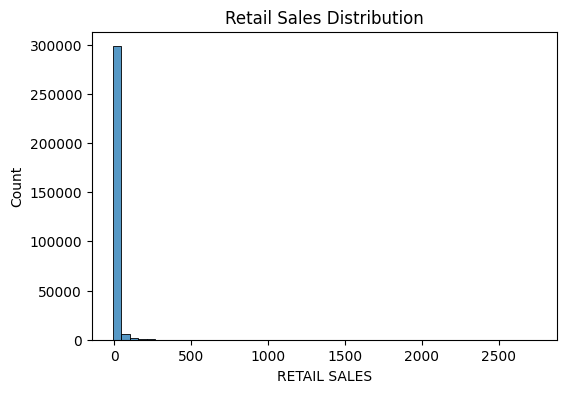

In [ ]:
# Retail Sales Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['RETAIL SALES'], bins=50)
plt.title("Retail Sales Distribution")
plt.show()


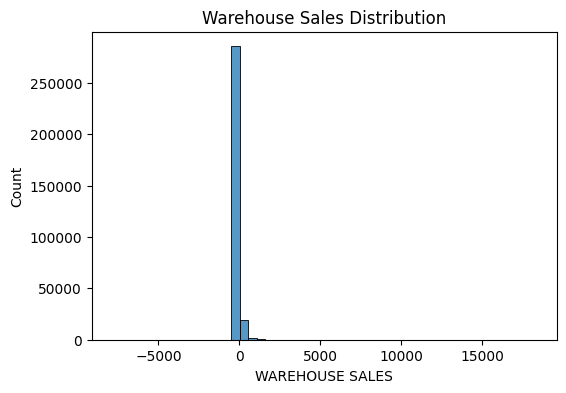

In [ ]:
# Warehouse Sales Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['WAREHOUSE SALES'], bins=50)
plt.title("Warehouse Sales Distribution")
plt.show()

Step 3.2:Retail vs Warehouse Relationship

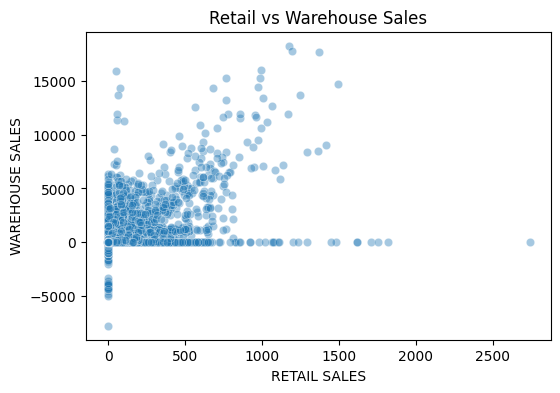

In [ ]:
# Retail vs Warehouse Relationship
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['RETAIL SALES'],
    y=df['WAREHOUSE SALES'],
    alpha=0.4
)
plt.title("Retail vs Warehouse Sales")
plt.show()


Step 3.3: Zero-Sales Pattern

In [ ]:
zero_retail_pct = (df['RETAIL SALES'] == 0).mean() * 100
zero_wh_pct = (df['WAREHOUSE SALES'] == 0).mean() * 100
pd.DataFrame({
    'Metric': ['Retail Zero %', 'Warehouse Zero %'],
    'Value': [zero_retail_pct, zero_wh_pct]
})


,Metric,Value
0,Retail Zero %,39.559232
1,Warehouse Zero %,31.513595


Step 3.4: Supplier-Level Contribution

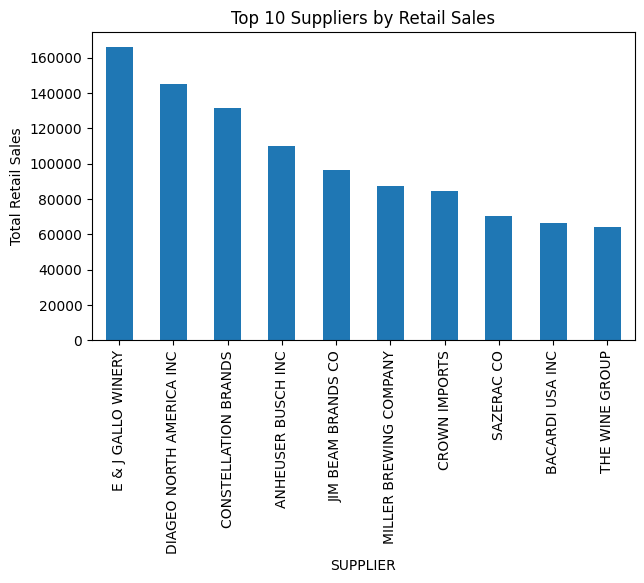

In [ ]:
supplier_sales = (
    df.groupby('SUPPLIER')['RETAIL SALES']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(7,4))
supplier_sales.plot(kind='bar')
plt.title("Top 10 Suppliers by Retail Sales")
plt.ylabel("Total Retail Sales")
plt.show()


Step 3.5: Item Type vs Sales Behavior

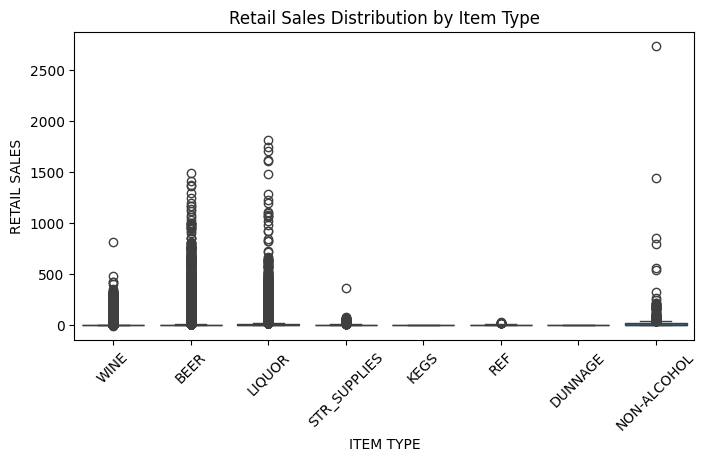

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(
    x='ITEM TYPE',
    y='RETAIL SALES',
    data=df
)
plt.xticks(rotation=45)
plt.title("Retail Sales Distribution by Item Type")
plt.show()


Step 3.6: Retail vs Warehouse Contribution (%)

In [ ]:
total_retail = df['RETAIL SALES'].sum()
total_wh = df['WAREHOUSE SALES'].sum()

pd.DataFrame({
    'Channel': ['Retail', 'Warehouse'],
    'Contribution %': [
        total_retail / (total_retail + total_wh) * 100,
        total_wh / (total_retail + total_wh) * 100
    ]
})


,Channel,Contribution %
0,Retail,21.733624
1,Warehouse,78.266376


Step 3.7: Product Activity & Seasonality

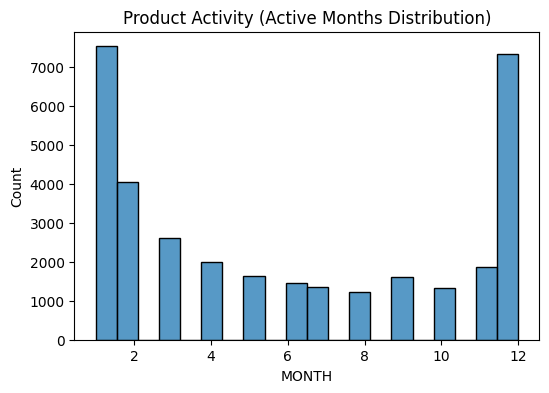

In [ ]:
# Product Activity Distribution
product_activity = df.groupby('ITEM CODE')['MONTH'].nunique()
plt.figure(figsize=(6,4))
sns.histplot(product_activity, bins=20)
plt.title("Product Activity (Active Months Distribution)")
plt.show()


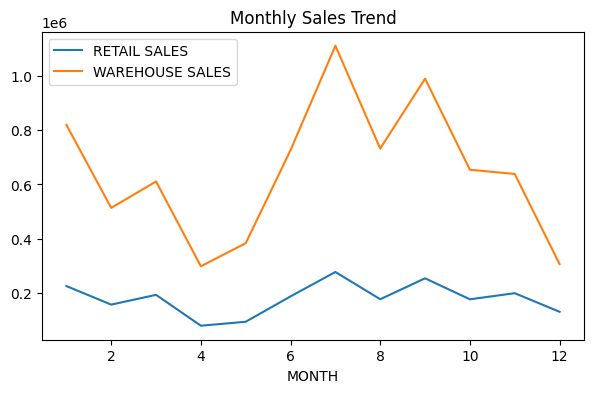

In [ ]:
# Monthly Sales Trend
monthly_sales = df.groupby('MONTH')[['RETAIL SALES','WAREHOUSE SALES']].sum()
monthly_sales.plot(figsize=(7,4))
plt.title("Monthly Sales Trend")
plt.show()


STEP 4: Product-Level Feature Engineering

In [ ]:
product_df = df.groupby('ITEM CODE').agg({
    'RETAIL SALES': ['mean', 'sum'],
    'WAREHOUSE SALES': ['mean', 'sum'],
    'RETAIL TRANSFERS': ['mean', 'sum'],
    'YEAR': 'nunique',
    'MONTH': 'nunique'
}).reset_index()
product_df.columns = [
    'ITEM_CODE',
    'AVG_RETAIL_SALES',
    'TOTAL_RETAIL_SALES',
    'AVG_WAREHOUSE_SALES',
    'TOTAL_WAREHOUSE_SALES',
    'AVG_RETAIL_TRANSFERS',
    'TOTAL_RETAIL_TRANSFERS',
    'ACTIVE_YEARS',
    'ACTIVE_MONTHS'
]
product_df.head()


,ITEM_CODE,AVG_RETAIL_SALES,TOTAL_RETAIL_SALES,AVG_WAREHOUSE_SALES,TOTAL_WAREHOUSE_SALES,AVG_RETAIL_TRANSFERS,TOTAL_RETAIL_TRANSFERS,ACTIVE_YEARS,ACTIVE_MONTHS
0,100002,0.170000,0.17,0.000000,0.0,0.0,0.0,1,1
1,100007,0.000000,0.00,1.000000,4.0,0.0,0.0,1,4
2,100008,0.000000,0.00,1.000000,3.0,0.0,0.0,1,3
3,100009,0.132308,1.72,1.384615,18.0,0.0,0.0,4,7
4,100011,0.000000,0.00,1.000000,3.0,0.0,0.0,2,3


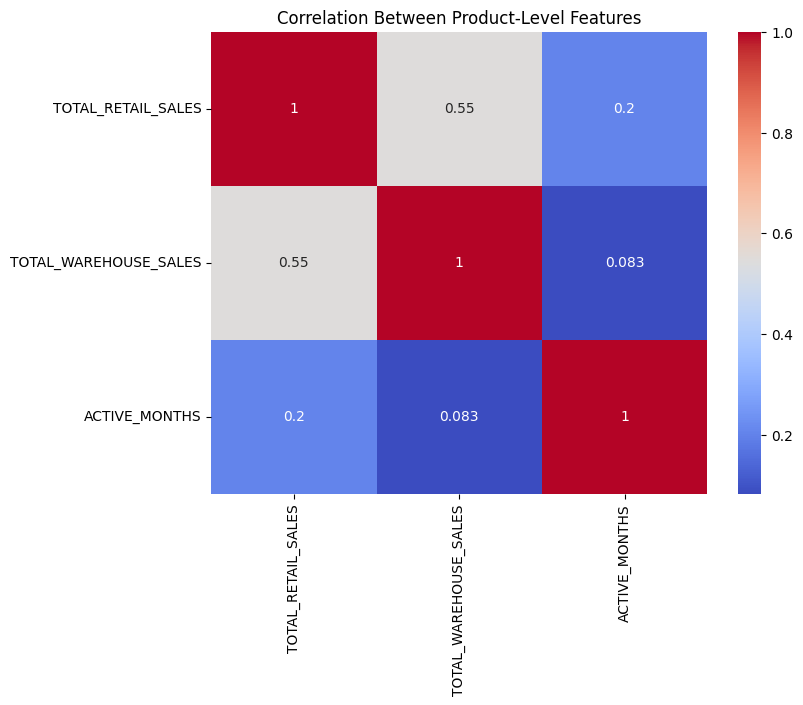

In [ ]:
#  correlation heat map
plt.figure(figsize=(8,6))
sns.heatmap(
    product_df[
        [
            'TOTAL_RETAIL_SALES',
            'TOTAL_WAREHOUSE_SALES',
            'ACTIVE_MONTHS'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Product-Level Features")
plt.show()


STEP 5: Zero-Aware Feature Engineering

5.1 Log Transformation (Preserves zeros)

In [ ]:
log_cols = [
    'AVG_RETAIL_SALES',
    'TOTAL_RETAIL_SALES',
    'AVG_WAREHOUSE_SALES',
    'TOTAL_WAREHOUSE_SALES'
]
for col in log_cols:
    product_df[f'LOG_{col}'] = np.log1p(product_df[col].clip(lower=0))


5.2 Zero-Flag Features (Business Interpretability)

In [ ]:
product_df['RETAIL_ZERO_FLAG'] = (product_df['TOTAL_RETAIL_SALES'] == 0).astype(int)
product_df['WAREHOUSE_ZERO_FLAG'] = (product_df['TOTAL_WAREHOUSE_SALES'] == 0).astype(int)


STEP 6: Final Feature Set for Clustering

In [ ]:
features = product_df[
    [
        'LOG_AVG_RETAIL_SALES',
        'LOG_TOTAL_RETAIL_SALES',
        'LOG_AVG_WAREHOUSE_SALES',
        'LOG_TOTAL_WAREHOUSE_SALES',
        'RETAIL_ZERO_FLAG',
        'WAREHOUSE_ZERO_FLAG',
        'ACTIVE_MONTHS'
    ]
]


In [ ]:
# Safety Check
features = features.replace([np.inf, -np.inf], np.nan)
features = features.fillna(0)
np.isfinite(features).all().all()


np.True_

STEP 7: Robust Scaling (Distance-safe)

In [ ]:
scaler = RobustScaler()
scaled_features = scaler.fit_transform(features)


STEP 8: Clustering Models

8.1 K-Means

8.1.1 : K-Means Parameter tuning

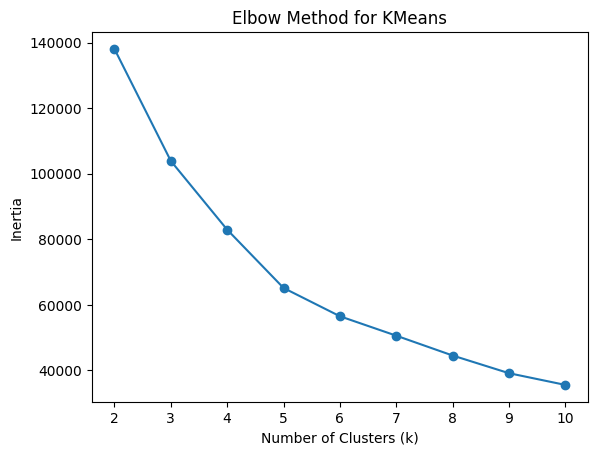

In [ ]:
#Tune n_clusters using Elbow Method
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()



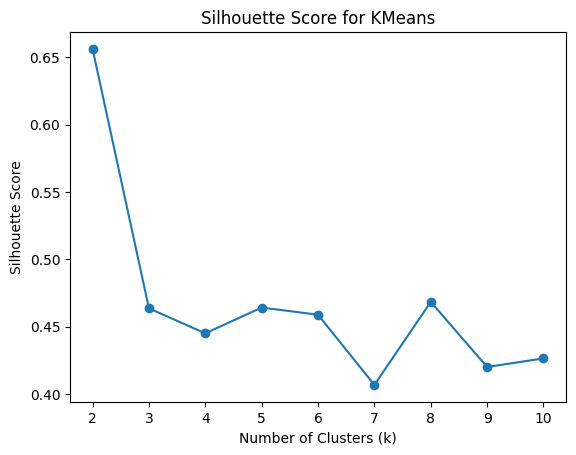

In [ ]:
#Tune n_clusters using Silhouette Score
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(scaled_features)
    sil_score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(sil_score)

plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for KMeans")
plt.show()


**Insights**



8.1.2 : Final Tuned K-Means Model





In [ ]:
# Fit Final Tuned Model
kmeans = KMeans(n_clusters=2,
                random_state=42,
                n_init=20,             #better convergence
                max_iter=300)          # almost always sufficient

product_df['KMeans_Cluster'] = kmeans.fit_predict(scaled_features)


In [ ]:
# Final Model Evaluation
sil_kmeans = silhouette_score(scaled_features, product_df['KMeans_Cluster'])
db_kmeans = davies_bouldin_score(scaled_features, product_df['KMeans_Cluster'])

print("Silhouette Score:", sil_kmeans)
print("Davies Bouldin Index:", db_kmeans)


Silhouette Score: 0.6562979549607774
Davies Bouldin Index: 0.7187797618675474


8.2 Hierarchical

8.2.1 :Hierarchical clustering – Parameter Tuning

In [ ]:
#Tune n_clusters using Silhouette Score
hc_results = []
for k in k_range:
    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    labels = hc.fit_predict(scaled_features)
    sil = silhouette_score(scaled_features, labels)
    hc_results.append({
        'k': k,
        'Silhouette Score': sil
    })
hc_silhouette_df = pd.DataFrame(hc_results)
hc_silhouette_df

,k,Silhouette Score
0,2,0.635659
1,3,0.583721
2,4,0.409032
3,5,0.409766
4,6,0.411668
5,7,0.410742
6,8,0.403730
7,9,0.393655
8,10,0.385587


8.2.2 : Final Tuned Hierarchical Model

In [ ]:
# fit Final Hierarchical Model
hc = AgglomerativeClustering(n_clusters=2,
                             linkage='ward')
product_df['HC_Cluster'] = hc.fit_predict(scaled_features)


In [ ]:
# Hierarchical Model Evaluation
sil_hierarchical = silhouette_score(scaled_features, product_df['HC_Cluster'])
db_hierarchical = davies_bouldin_score(scaled_features, product_df['HC_Cluster'])
print("Silhouette Score:", sil_hierarchical)
print("Davies Bouldin Index:", db_hierarchical)

Silhouette Score: 0.635658714959235
Davies Bouldin Index: 0.7739184073773545


8.3 DBSCAN

8.3.1 : DBSCAN Parameter Tuning

In [ ]:
# Parameter Tuning
eps_values = [0.8, 1.0, 1.2, 1.4]
min_samples_values = [4, 5, 7, 9]

dbscan_results = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(scaled_features)

        # Ignore cases where all points are noise
        if len(set(labels)) <= 1:
            continue

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).mean() * 100

        # Silhouette only if valid
        try:
            sil = silhouette_score(scaled_features[labels != -1],
                                   labels[labels != -1])
        except:
            sil = np.nan

        dbscan_results.append({
            'eps': eps,
            'min_samples': ms,
            'clusters': n_clusters,
            'noise_%': round(noise_pct, 2),
            'silhouette_score': round(sil, 3)
        })

dbscan_results_df = pd.DataFrame(dbscan_results)
dbscan_results_df.sort_values(by='silhouette_score', ascending=False)


,eps,min_samples,clusters,noise_%,silhouette_score
6,1.0,7,2,0.11,0.756
2,0.8,7,6,0.27,0.210
3,0.8,9,6,0.37,0.209
0,0.8,4,6,0.17,0.200
1,0.8,5,7,0.18,0.197
4,1.0,4,1,0.08,NaN
5,1.0,5,1,0.09,NaN
7,1.0,9,1,0.19,NaN
8,1.2,4,1,0.04,NaN
9,1.2,5,1,0.05,NaN


In [ ]:
# Select Final DBSCAN Model
best_params = dbscan_results_df.sort_values(
    by='silhouette_score', ascending=False
).iloc[0]

best_params


,6
eps,1.000
min_samples,7.000
clusters,2.000
noise_%,0.110
silhouette_score,0.756


8.3.2 : DBSCAN Final Model

In [ ]:
# Fit the final Model
dbscan_final = DBSCAN(
    eps=best_params['eps'],
    min_samples=int(best_params['min_samples'])
)
dbscan_labels = dbscan_final.fit_predict(scaled_features)
# Add to product-level dataframe
product_df['DBSCAN_CLUSTER'] = dbscan_labels



In [ ]:
# Model Evaluation

# Mask to remove noise points
mask = dbscan_labels != -1

# Number of clusters (excluding noise)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print(f"Number of clusters (excluding noise): {n_clusters}")
print(f"Noise percentage: {(~mask).mean() * 100:.2f}%")

# Compute metrics only if valid clusters exist
if n_clusters > 1:
    sil_score_dbscan = silhouette_score(
        scaled_features[mask],
        dbscan_labels[mask]
    )

    db_score_dbscan = davies_bouldin_score(
        scaled_features[mask],
        dbscan_labels[mask]
    )

    print(f"Silhouette Score (DBSCAN): {sil_score_dbscan:.3f}")
    print(f"Davies-Bouldin Score (DBSCAN): {db_score_dbscan:.3f}")
else:
    print("Not enough clusters to compute evaluation metrics.")


Number of clusters (excluding noise): 2
Noise percentage: 0.11%
Silhouette Score (DBSCAN): 0.756
Davies-Bouldin Score (DBSCAN): 0.200


STEP 9: Model Comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['KMeans', 'Hierarchical','dbscan_final'],
    'Silhouette Score': [sil_kmeans, sil_hierarchical,sil_score_dbscan],
    'Davies Bouldin Index': [db_kmeans, db_hierarchical,db_score_dbscan]
})
display(comparison)



,Model,Silhouette Score,Davies Bouldin Index
0,KMeans,0.656298,0.718780
1,Hierarchical,0.635659,0.773918
2,dbscan_final,0.756179,0.199917


STEP 10: Cluster Interpretation

In [ ]:
# Exclude noise points for profiling
profile_df = product_df[product_df['DBSCAN_CLUSTER'] != -1].copy()

# Select numeric features for summary
numeric_cols = [
    'AVG_RETAIL_SALES',
    'TOTAL_RETAIL_SALES',
    'AVG_WAREHOUSE_SALES',
    'TOTAL_WAREHOUSE_SALES',
    'ACTIVE_MONTHS'
]

# Cluster-wise summary
cluster_profile = (
    profile_df
    .groupby('DBSCAN_CLUSTER')[numeric_cols]
    .mean()
    .round(2)
)

cluster_profile


,AVG_RETAIL_SALES,TOTAL_RETAIL_SALES,AVG_WAREHOUSE_SALES,TOTAL_WAREHOUSE_SALES,ACTIVE_MONTHS
DBSCAN_CLUSTER,,,,,
0,2.74,57.59,9.56,178.63,6.0
1,94.64,2138.15,3376.78,72205.72,11.8


In [ ]:
# Cluster Size Distribution
cluster_counts = profile_df['DBSCAN_CLUSTER'].value_counts().sort_index()
cluster_counts


,count
DBSCAN_CLUSTER,
0,34014
1,5


STEP 10: PCA

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_features)

plt.figure(figsize=(7,5))
sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=product_df['KMeans_Cluster'],
    palette='Set2'
)
plt.title("Product Clusters (PCA Visualization)")
plt.show()

STEP 11: Final Output for Report / Dashboard

In [ ]:
# Final dataset for Power BI
dashboard_df = product_df.copy()

dashboard_df.to_csv(
    "clustered_product_sales_for_powerbi.csv",
    index=False
)


In [ ]:
import pandas as pd
data=pd.read_csv("/content/clustered_product_sales.csv")

In [ ]:
data.head()

,ITEM_CODE,AVG_RETAIL_SALES,TOTAL_RETAIL_SALES,AVG_WAREHOUSE_SALES,TOTAL_WAREHOUSE_SALES,AVG_RETAIL_TRANSFERS,TOTAL_RETAIL_TRANSFERS,ACTIVE_YEARS,ACTIVE_MONTHS,LOG_AVG_RETAIL_SALES,LOG_TOTAL_RETAIL_SALES,LOG_AVG_WAREHOUSE_SALES,LOG_TOTAL_WAREHOUSE_SALES,RETAIL_ZERO_FLAG,WAREHOUSE_ZERO_FLAG,KMeans_Cluster,HC_Cluster,DBSCAN_CLUSTER
0,100002,0.170000,0.17,0.000000,0.0,0.0,0.0,1,1,0.157004,0.157004,0.000000,0.000000,0,1,0,1,0
1,100007,0.000000,0.00,1.000000,4.0,0.0,0.0,1,4,0.000000,0.000000,0.693147,1.609438,1,0,0,1,0
2,100008,0.000000,0.00,1.000000,3.0,0.0,0.0,1,3,0.000000,0.000000,0.693147,1.386294,1,0,0,1,0
3,100009,0.132308,1.72,1.384615,18.0,0.0,0.0,4,7,0.124258,1.000632,0.869038,2.944439,0,0,0,1,0
4,100011,0.000000,0.00,1.000000,3.0,0.0,0.0,2,3,0.000000,0.000000,0.693147,1.386294,1,0,0,1,0


In [ ]:
data.columns.tolist()

['ITEM_CODE',
 'AVG_RETAIL_SALES',
 'TOTAL_RETAIL_SALES',
 'AVG_WAREHOUSE_SALES',
 'TOTAL_WAREHOUSE_SALES',
 'AVG_RETAIL_TRANSFERS',
 'TOTAL_RETAIL_TRANSFERS',
 'ACTIVE_YEARS',
 'ACTIVE_MONTHS',
 'LOG_AVG_RETAIL_SALES',
 'LOG_TOTAL_RETAIL_SALES',
 'LOG_AVG_WAREHOUSE_SALES',
 'LOG_TOTAL_WAREHOUSE_SALES',
 'RETAIL_ZERO_FLAG',
 'WAREHOUSE_ZERO_FLAG',
 'KMeans_Cluster',
 'HC_Cluster',
 'DBSCAN_CLUSTER']